# Analysis

Pure pandas over `results_v2.jsonl`; **never calls an API**. Narrative order mirrors spec §6: noise floor & placebo gate first, then per-axis results, localization (flip rates), verbosity, self-preference, the validity anchor, and issue matching. Figures/tables are written to `artifacts/figures/`.

Set `RUN_NAME` below — use `results_v2` for the real run (or a mock run to dry-run the whole notebook before any spend).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))  # run from notebooks/
from prjudge.config import load_config
config = load_config()
from prjudge import analysis as A
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
RUN_NAME = 'results_v2'   # or a mock run name to validate the notebook first
FIG = A.figures_dir(config)
df = A.load_results(config, RUN_NAME)
print('scored rows:', len(df), '| unparsed:', A.load_results.n_unparsed)
print('judges:', sorted(df['judge'].unique()), '| variants:', df['variant'].nunique())

scored rows: 1440 | unparsed: 0
judges: ['claude', 'gpt'] | variants: 8


## 1. Noise floor & placebo gate
Every reported flip rate and Δ is compared against trial-to-trial noise. The **placebo axis must show ≈0 effect** — if it doesn't, the noise model is wrong and results are not reported until resolved.

In [2]:
nf = A.noise_floor(df)
display(nf)
mnf = A.modal_noise_floor(df)
display(mnf)
gate = A.placebo_gate(df)
print('PLACEBO GATE:', 'PASS' if gate['passes'] else 'FAIL')
print(gate)

,item,item_text,n_cells,noise_flip_rate
0,1,Introduces a plausible correctness bug or regr...,480,0.231250
1,2,Adequately handles error/edge cases in the cod...,480,0.195833
2,3,Changes are covered by new or updated tests,480,0.035417
3,4,Scoped to one coherent purpose,480,0.058333
4,5,Introduces a security or data-safety concern,480,0.027083
5,6,Introduces an obvious performance regression,480,0.027083
6,7,Consistent with the surrounding code's convent...,480,0.154167
7,8,Understandable without external context,480,0.004167
8,9,A competent reviewer would request changes bef...,480,0.227083
9,10,I would approve this PR as-is,480,0.241667


,item,item_text,n_cells,modal_noise_floor
0,1,Introduces a plausible correctness bug or regr...,480,0.088820
1,2,Adequately handles error/edge cases in the cod...,480,0.075217
2,3,Changes are covered by new or updated tests,480,0.013603
3,4,Scoped to one coherent purpose,480,0.022405
4,5,Introduces a security or data-safety concern,480,0.010402
5,6,Introduces an obvious performance regression,480,0.010402
6,7,Consistent with the surrounding code's convent...,480,0.059214
7,8,Understandable without external context,480,0.001600
8,9,A competent reviewer would request changes bef...,480,0.087220
9,10,I would approve this PR as-is,480,0.092821


PLACEBO GATE: PASS
{'observed_mean_abs_delta': 0.3888888888888889, 'observed_median_abs_delta': 0.0, 'null_mean_abs_delta': 0.5837377017694493, 'null_p95_abs_delta': 0.7447318333048788, 'p_value': 0.9818, 'passes': True, 'n': 60, 'n_boot': 10000, 'noise_floor_mean_item_rate': 0.12020833333333333, 'signed_effect_by_judge': {'claude': {'mean_delta': -0.055555555555555594, 'wilcoxon_p': 0.5081210926186213, 'n': 30}, 'gpt': {'mean_delta': 0.16666666666666666, 'wilcoxon_p': 0.2002787951645878, 'n': 30}}}


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


## 2. Primary — Δ(aggregate) per axis
Δ = variant − same-PR baseline, paired within (PR, judge). Axes ranked by median |Δ| per judge, with Wilcoxon and a PR-random-intercept mixed model.

In [3]:
summary = A.delta_summary(df)
display(summary)
display(A.wilcoxon_by_axis(df))
mm = A.mixedlm_by_axis(df)
display(mm if not mm.empty else 'statsmodels unavailable')

,judge,axis,n,mean_delta,median_delta,mean_abs_delta,median_abs_delta
0,claude,origin,60,2.777778e-02,0.0,0.427778,0.333333
1,claude,verbosity,90,-8.148148e-02,0.0,0.451852,0.333333
2,claude,prestige,30,-4.440892e-17,0.0,0.422222,0.166667
3,claude,placebo,30,-5.555556e-02,0.0,0.322222,0.000000
4,gpt,verbosity,90,8.518519e-02,0.0,0.514815,0.333333
5,gpt,placebo,30,1.666667e-01,0.0,0.455556,0.166667
6,gpt,origin,60,-7.401487e-18,0.0,0.466667,0.000000
7,gpt,prestige,30,3.333333e-02,0.0,0.300000,0.000000


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


,judge,axis,n,median_delta,wilcoxon_stat,p_value,p_adj_bh
0,claude,origin,60,0.0,299.5,0.799019,0.909342
1,claude,placebo,30,0.0,42.0,0.508121,0.909342
2,claude,prestige,30,0.0,58.0,0.909342,0.909342
3,claude,verbosity,90,0.0,456.5,0.254572,0.909342
4,gpt,origin,60,0.0,199.5,0.936346,0.936346
5,gpt,placebo,30,0.0,37.5,0.200279,0.466329
6,gpt,prestige,30,0.0,23.0,0.646034,0.861378
7,gpt,verbosity,90,0.0,472.0,0.233165,0.466329


,judge,axis,term,estimate,p_value,note,p_adj_bh
0,claude,origin,origin_claude,0.044444,0.753263,,1.000000
1,claude,origin,origin_gpt,0.011111,0.937363,,1.000000
2,claude,placebo,placebo,-0.055556,0.738567,,1.000000
3,claude,prestige,repo_masked,0.000000,1.000000,,1.000000
4,claude,verbosity,verb_terse,-0.011111,0.940519,,1.000000
5,claude,verbosity,verb_pad2x,-0.211111,0.156270,,1.000000
6,claude,verbosity,verb_pad4x,-0.022222,0.881368,,1.000000
7,gpt,origin,origin_claude,0.055556,0.767460,,0.900899
8,gpt,origin,origin_gpt,-0.055556,0.767460,,0.900899
9,gpt,placebo,placebo,0.166667,0.300047,,0.900899


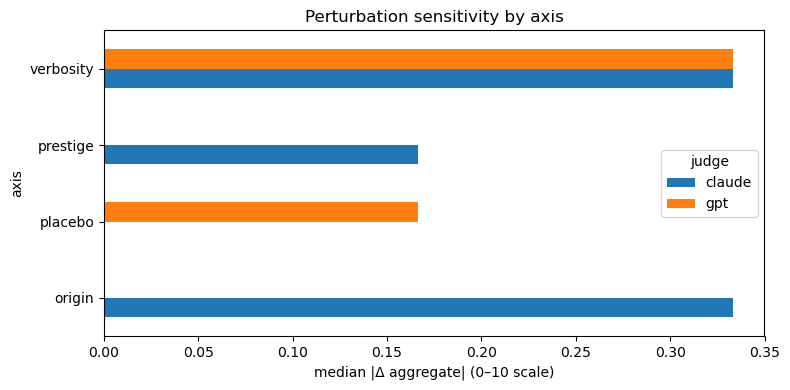

In [4]:
# Figure: median |Δ| by axis, per judge
piv = summary.pivot(index='axis', columns='judge', values='median_abs_delta')
ax = piv.plot(kind='barh', figsize=(8, 4))
ax.set_xlabel('median |Δ aggregate| (0–10 scale)'); ax.set_title('Perturbation sensitivity by axis')
plt.tight_layout(); plt.savefig(FIG / 'axis_sensitivity.png', dpi=150); plt.show()

## 2b. Equivalence bounds (TOST) & minimum detectable effect — RQ3

Converts each null into a bounded claim: `tost_p < .05` establishes |mean Δ| < margin
(±0.5 points ≈ half a checklist item on the 0–10 aggregate); `equiv_margin_min` is the
smallest margin at which equivalence holds (the widest |bound| of the 90% CI of mean Δ);
`mde_80` is the smallest true mean shift the design could have detected with 80% power.

In [5]:
eq = A.equivalence_by_axis(df, margin=0.5)
display(eq.round(3))
print('all axes equivalent within ±0.5:', bool((eq['tost_p'] < 0.05).all()))
print('largest equiv_margin_min:', round(float(eq['equiv_margin_min'].max()), 3),
      '| largest mde_80:', round(float(eq['mde_80'].max()), 3))

,judge,axis,n,mean_delta,sd_delta,ci90_lo,ci90_hi,margin,tost_p,equiv_margin_min,mde_80
0,claude,origin,60,0.028,0.636,-0.109,0.165,0.5,0.000,0.165,0.234
1,claude,placebo,30,-0.056,0.547,-0.225,0.114,0.5,0.000,0.225,0.290
2,claude,prestige,30,-0.000,0.689,-0.214,0.214,0.5,0.000,0.214,0.365
3,claude,verbosity,90,-0.081,0.740,-0.211,0.048,0.5,0.000,0.211,0.221
4,gpt,origin,60,-0.000,0.826,-0.178,0.178,0.5,0.000,0.178,0.304
5,gpt,placebo,30,0.167,0.731,-0.060,0.393,0.5,0.009,0.393,0.387
6,gpt,prestige,30,0.033,0.621,-0.159,0.226,0.5,0.000,0.226,0.329
7,gpt,verbosity,90,0.085,0.930,-0.078,0.248,0.5,0.000,0.248,0.278


all axes equivalent within ±0.5: True
largest equiv_margin_min: 0.393 | largest mde_80: 0.387


## 3. Bias localization — per-item flip rates
Which judgments absorb each perturbation. Padding flipping item 8 (understandability) is semi-defensible; flipping item 1 or 3 — code the padding never touched — is the damning finding. The most quotable output.

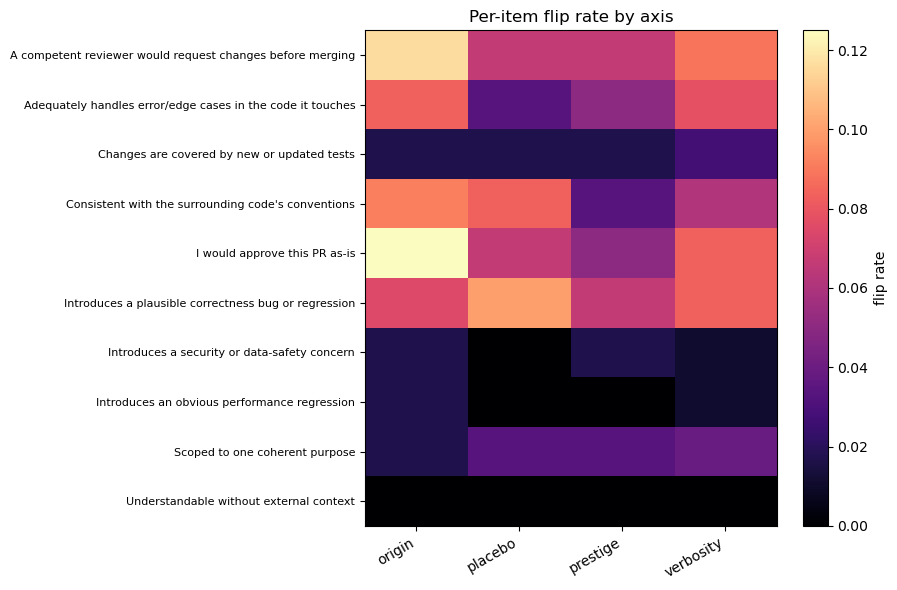

axis,origin,placebo,prestige,verbosity
item_text,,,,
A competent reviewer would request changes before merging,0.117,0.067,0.067,0.089
Adequately handles error/edge cases in the code it touches,0.083,0.033,0.050,0.078
Changes are covered by new or updated tests,0.017,0.017,0.017,0.028
Consistent with the surrounding code's conventions,0.092,0.083,0.033,0.061
I would approve this PR as-is,0.125,0.067,0.050,0.083
Introduces a plausible correctness bug or regression,0.075,0.100,0.067,0.083
Introduces a security or data-safety concern,0.017,0.000,0.017,0.011
Introduces an obvious performance regression,0.017,0.000,0.000,0.011
Scoped to one coherent purpose,0.017,0.033,0.033,0.039


,axis,item,item_text,flip_rate,modal_noise_floor,excess_flip_rate
0,origin,1,Introduces a plausible correctness bug or regr...,0.083,0.089,-0.005
10,origin,1,Introduces a plausible correctness bug or regr...,0.067,0.089,-0.022
20,placebo,1,Introduces a plausible correctness bug or regr...,0.100,0.089,0.011
30,prestige,1,Introduces a plausible correctness bug or regr...,0.067,0.089,-0.022
40,verbosity,1,Introduces a plausible correctness bug or regr...,0.100,0.089,0.011
...,...,...,...,...,...,...
29,placebo,10,I would approve this PR as-is,0.067,0.093,-0.026
39,prestige,10,I would approve this PR as-is,0.050,0.093,-0.043
49,verbosity,10,I would approve this PR as-is,0.117,0.093,0.024
59,verbosity,10,I would approve this PR as-is,0.083,0.093,-0.009


In [6]:
fr = A.flip_rates_with_noise_floor(df)
heat = fr.pivot_table(index='item_text', columns='axis', values='flip_rate', aggfunc='mean')
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(heat.values, aspect='auto', cmap='magma')
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=30, ha='right')
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index, fontsize=8)
fig.colorbar(im, label='flip rate'); ax.set_title('Per-item flip rate by axis')
plt.tight_layout(); plt.savefig(FIG / 'flip_rate_heatmap.png', dpi=150); plt.show()
display(heat.round(3))
# modal_noise_floor + excess_flip_rate per (axis, item) — the correct-units reference
# (majority-vote noise floor, not raw trial disagreement) plus the placebo axis's own
# flip rate as an active-control column (already in `heat` above).
display(fr[['axis', 'item', 'item_text', 'flip_rate', 'modal_noise_floor', 'excess_flip_rate']]
        .sort_values(['item', 'axis']).round(3))

## 4. Verbosity dose–response
Monotonic score-vs-length trend across terse < baseline < 2× < 4×, with the sensitivity check excluding the 4 short-description PRs. The `verb_terse` cells of the 4 terse-waived PRs (spec §4.2) are excluded by default (`exclude_terse_waived=True`).

In [7]:
print('all PRs:'); display(A.verbosity_trend(df))
print('excluding short-desc PRs:'); display(A.verbosity_trend(df, exclude_short_desc=True))

all PRs:


,judge,spearman_rho,spearman_p,mean_verb_terse,mean_baseline,mean_verb_pad2x,mean_verb_pad4x
0,claude,-0.066868,0.223601,7.888889,7.566667,7.355556,7.544444
1,gpt,-0.090941,0.097578,8.190476,7.300000,7.322222,7.277778


excluding short-desc PRs:


,judge,spearman_rho,spearman_p,mean_verb_terse,mean_baseline,mean_verb_pad2x,mean_verb_pad4x
0,claude,-0.061428,0.281726,7.824561,7.50,7.357143,7.488095
1,gpt,-0.098201,0.084819,8.192982,7.25,7.250000,7.214286


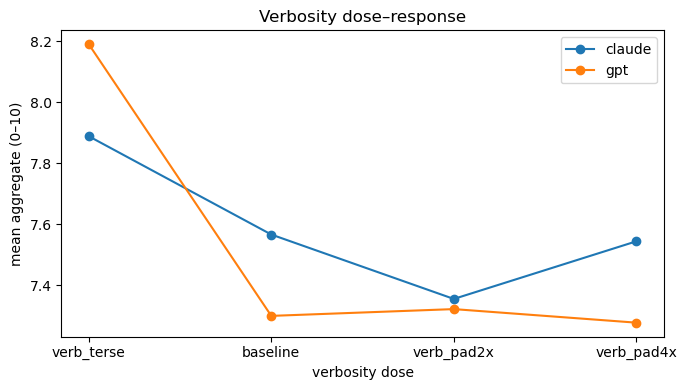

In [8]:
vt = A.verbosity_trend(df)
order = A.VERBOSITY_ORDER
fig, ax = plt.subplots(figsize=(7, 4))
for _, r in vt.iterrows():
    ax.plot(order, [r[f'mean_{v}'] for v in order], marker='o', label=r['judge'])
ax.set_ylabel('mean aggregate (0–10)'); ax.set_xlabel('verbosity dose')
ax.set_title('Verbosity dose–response'); ax.legend()
plt.tight_layout(); plt.savefig(FIG / 'verbosity_trend.png', dpi=150); plt.show()

## 5. Self-preference 2×2
Claimed-family × judge-family. The interaction (own-family minus other-family Δ) is the self-preference estimate.

In [9]:
display(A.self_preference(df))

variant,judge,origin_claude,origin_gpt,claude_minus_gpt
0,claude,0.044444,0.011111,0.033333
1,gpt,0.055556,-0.055556,0.111111


## 6. Validity anchor — item 9 vs human `has_requested_changes`
Robustness is necessary, not sufficient: a judge with near-zero sensitivity **and** near-zero validity is vacuously stable. Direct binary agreement plus Spearman of the baseline aggregate with `requested_change_count`.

In [10]:
display(A.item9_validity(df))

,judge,n,item9_vs_human_agreement,item9_vs_human_kappa,judge_request_rate,human_request_rate,spearman_agg_vs_reqcount,spearman_p
0,claude,30,0.566667,-0.226415,0.300000,0.133333,-0.191599,0.310451
1,gpt,30,0.533333,0.018692,0.466667,0.133333,-0.249736,0.183209


## 7. Issue matching — detection overlap & shift
Judge-reported issues matched to human-flagged locations (same file, line in the comment's `diff_hunk` range). Baseline = validity evidence; under perturbation, a detection drop is the mechanism story.

In [11]:
im = A.issue_matching(config, df)
display(im.pivot(index='variant', columns='judge', values='detection').round(3))

judge,claude,gpt
variant,,
baseline,0.478,0.356
origin_claude,0.489,0.333
origin_gpt,0.478,0.344
placebo,0.489,0.322
repo_masked,0.456,0.344
verb_pad2x,0.522,0.356
verb_pad4x,0.500,0.322
verb_terse,0.489,0.333


## 8. 2D judge characterization
Each judge on validity × worst-case bias magnitude. The sensitive+valid quadrant is the most dangerous deployment profile: right on average, swayed by surface features.

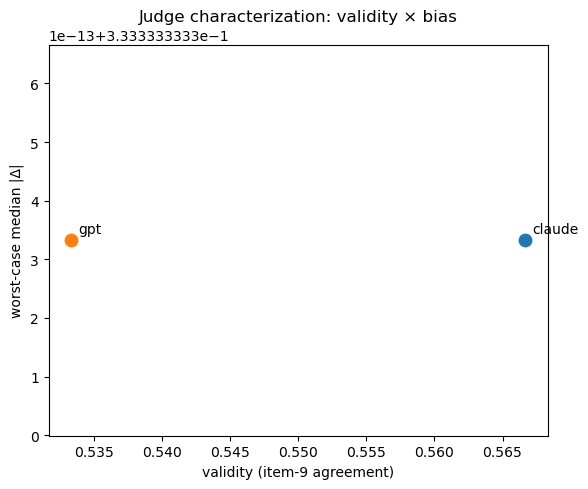

In [12]:
val = A.item9_validity(df).set_index('judge')['item9_vs_human_agreement']
bias = A.delta_summary(df).groupby('judge')['median_abs_delta'].max()
fig, ax = plt.subplots(figsize=(6, 5))
for j in val.index:
    ax.scatter(val[j], bias.get(j, np.nan), s=80)
    ax.annotate(j, (val[j], bias.get(j, np.nan)), xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('validity (item-9 agreement)'); ax.set_ylabel('worst-case median |Δ|')
ax.set_title('Judge characterization: validity × bias')
plt.tight_layout(); plt.savefig(FIG / 'judge_characterization.png', dpi=150); plt.show()

## 9. Placebo as an active control (secondary view)

SECONDARY — does not replace §2's primary Δ-vs-baseline analysis. The placebo gate
(§1) shows the placebo axis itself sits near the noise floor rather than at a true
zero, so this reframes each axis's Δ against the same judge's own Δ_placebo
(paired per-PR), rather than against zero.

In [13]:
display(A.placebo_active_control(df))

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


,judge,axis,n,mean_delta_axis,mean_delta_placebo,mean_diff_vs_placebo,median_diff_vs_placebo,wilcoxon_stat,wilcoxon_p
0,claude,origin,60,2.777778e-02,-0.055556,0.083333,0.0,212.0,0.327859
1,claude,prestige,30,-4.440892e-17,-0.055556,0.055556,0.0,78.5,0.504266
2,claude,verbosity,90,-8.148148e-02,-0.055556,-0.025926,0.0,707.0,0.759318
3,gpt,origin,60,-1.480297e-17,0.166667,-0.166667,0.0,135.5,0.198026
4,gpt,prestige,30,3.333333e-02,0.166667,-0.133333,0.0,31.5,0.554619
5,gpt,verbosity,90,8.518519e-02,0.166667,-0.081481,0.0,413.5,0.825409
